<a href="https://colab.research.google.com/github/ValeriiSlynko/IT-STEP-Practice/blob/master/Practice_Pandas/HmWrk_Pd(metrics_MAE_MSE_R2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Дані

In [17]:
import pandas as pd

In [18]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/ITStep-AI/refs/heads/superwised_learning/data/customer_spending.csv")

* Показуємо поточний датасет із виводом перших 10 ряків

In [19]:
df.head(10)

,annual_income,account_tenure_days,age,engagement_score,support_tickets,annual_spending
0,57964.98,1170,65,35.95,5,218.46
1,27667.36,856,58,14.56,2,16.51
2,74068.69,1178,31,33.26,2,240.06
3,82232.89,741,33,87.93,2,242.77
4,16763.02,497,31,10.22,0,130.61
5,23951.86,1211,31,95.83,3,123.98
6,52591.63,1011,61,10.75,5,170.94
7,41194.77,587,38,36.20,0,144.48
8,48569.90,1438,40,60.63,3,137.69
9,30663.42,38,52,83.78,3,122.81



# Опис даних

Ці дані користувачів онлайн-сервісу **Shoply** — сайту, де люди купують товари та оформлюють підписки. Для кожного користувача зібрана інформація про його активність, дохід та взаємодію із сайтом.

* **annual_income** — скільки грошей користувач заробляє за рік
* **account_tenure_days** — скільки днів користувач зареєстрований на сайті
* **age** — вік користувача
* **engagement_score** — наскільки активно користувач користується сайтом
* **support_tickets** — скільки разів користувач звертався до служби підтримки
* **annual_spending** — скільки грошей користувач витрачає на сайті за рік


Потрібно спрогнозувати **витрати користувача** на сайті за рік

* Визначаємо кількість рядків та стовпчиків

In [20]:
rows, columns = df.shape
print(f"Таблиця має '{rows}' рядків та '{columns}' стовпчиків/колнок")

Таблиця має '6520' рядків та '6' стовпчиків/колнок


* Отримуємо назви всіх стовпчиків та типи даних

In [21]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6520 entries, 0 to 6519
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   annual_income        6520 non-null   float64
 1   account_tenure_days  6520 non-null   int64  
 2   age                  6520 non-null   int64  
 3   engagement_score     6520 non-null   float64
 4   support_tickets      6520 non-null   int64  
 5   annual_spending      6520 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 305.8 KB



* Дивимось кількість пропусків у стовпчиків

In [22]:
df.isna().sum()

,0
annual_income,0
account_tenure_days,0
age,0
engagement_score,0
support_tickets,0
annual_spending,0


# Завдання 1
Розділіть дані на ознаки для моделі(Х) та цільову змінну(y)

In [23]:
X = df.drop(columns=["annual_spending"])
y = df["annual_spending"]

In [24]:
# Після розділення даних перевіряємо 'Х'
X

,annual_income,account_tenure_days,age,engagement_score,support_tickets
0,57964.98,1170,65,35.95,5
1,27667.36,856,58,14.56,2
2,74068.69,1178,31,33.26,2
3,82232.89,741,33,87.93,2
4,16763.02,497,31,10.22,0
...,...,...,...,...,...
6515,22014.22,4428,41,94.80,3
6516,26082.07,71,42,44.61,1
6517,30162.82,178,18,17.03,3
6518,61570.17,312,22,54.99,1


In [25]:
# Після розділення даних перевіряємо 'y'
y

,annual_spending
0,218.46
1,16.51
2,240.06
3,242.77
4,130.61
...,...
6515,141.48
6516,115.99
6517,75.06
6518,85.78


# Завдання 2
Розділіть дані на тренувальну та тестову вибірку

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% даних залишаємо для тестування
    random_state=42    # фіксуємо випадковість для відтворюваності результату
)

print("Тренувальна вибірка:", X_train.shape)
print("Тестова вибірка:", X_test.shape)

Тренувальна вибірка: (5216, 5)
Тестова вибірка: (1304, 5)


#Завдання 3
Нетренуйте дерево рішень на тренувальній вибірці

При створенні моделі використовуйте параметри за замовчуванням

In [27]:
from sklearn.tree import DecisionTreeRegressor

model_tree = DecisionTreeRegressor()
model_tree.fit(X_train, y_train)

DecisionTreeRegressor()

# Завдання 4
Спронозуйте витрати користувача для тренувальних даних та порівняйте зі справжніми

Використайте метрики MAE, MSE, R2

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
predict = model_tree.predict(X_train)

# Розраховуємо метрики
mae = mean_absolute_error(y_train, predict)
mse = mean_squared_error(y_train, predict)
rmse = np.sqrt(mse)  # Беремо корінь від MSE
r2 = r2_score(y_train, predict)

print("=== ОСНОВНІ МЕТРИКИ МОДЕЛІ (Витрати користувача) ===")
print(f"MAE  (Mean Absolute Error): {mae:.2f} ₹ (середня помилка)")
print(f"MSE  (Mean Squared Error):  {mse:.2f} ₹² (квадратична помилка)")
print(f"RMSE (Root MSE):            {rmse:.2f} ₹ (помилка з урахуванням викидів)")
print(f"R² Score:                   {r2:.4f} ({r2*100:.2f}% поясненої дисперсії)")

=== ОСНОВНІ МЕТРИКИ МОДЕЛІ (Витрати користувача) ===
MAE  (Mean Absolute Error): 0.00 ₹ (середня помилка)
MSE  (Mean Squared Error):  0.00 ₹² (квадратична помилка)
RMSE (Root MSE):            0.00 ₹ (помилка з урахуванням викидів)
R² Score:                   1.0000 (100.00% поясненої дисперсії)


# Завдання 5
Спронозуйте витрати користувача для тестових даних та порівняйте зі справжніми

Використайте метрики MAE, MSE, R2

In [29]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
predict = model_tree.predict(X_test)

# 2. Розраховуємо метрики
mae = mean_absolute_error(y_test, predict)
mse = mean_squared_error(y_test, predict)
rmse = np.sqrt(mse)  # Беремо корінь від MSE
r2 = r2_score(y_test, predict)

print("=== ОСНОВНІ МЕТРИКИ МОДЕЛІ (витрати користувача) ===")
print(f"MAE  (Mean Absolute Error): {mae:.2f} ₹ (середня помилка)")
print(f"MSE  (Mean Squared Error):  {mse:.2f} ₹² (квадратична помилка)")
print(f"RMSE (Root MSE):            {rmse:.2f} ₹ (помилка з урахуванням викидів)")
print(f"R² Score:                   {r2:.4f} ({r2*100:.2f}% поясненої дисперсії)")

=== ОСНОВНІ МЕТРИКИ МОДЕЛІ (витрати користувача) ===
MAE  (Mean Absolute Error): 33.16 ₹ (середня помилка)
MSE  (Mean Squared Error):  1736.54 ₹² (квадратична помилка)
RMSE (Root MSE):            41.67 ₹ (помилка з урахуванням викидів)
R² Score:                   0.5075 (50.75% поясненої дисперсії)


# Завдання 6
Для різних значень параметра `max_depth` натренуйте модель та порахуйте метрику `MAE` на тренувальних та тестових даних

Отримайте відповідно 2 списки -- `train_mae` та `test_mae`
візуалізуйте їх

In [53]:
# Тренуємо модель та рахуємо метрику 'MAE' (Mean Absolute Error) — середня абсолютна похибка

train_MAE = []
test_MAE = []

max_depth = range(1, 15)

for depth in max_depth:
  tree = DecisionTreeRegressor(max_depth=depth)
  tree.fit(X_train, y_train)

  train_predict = tree.predict(X_train)
  test_predict = tree.predict(X_test)

  MAE_test = mean_absolute_error(y_test, test_predict)
  MAE_train = mean_absolute_error(y_train, train_predict)

  train_MAE.append(MAE_train)
  test_MAE.append(MAE_test)


In [54]:
train_MAE

[35.63177445860969,
 31.6251986946527,
 28.224786744448036,
 25.784014724992396,
 23.84374721400964,
 22.670991151668908,
 21.590362728677476,
 20.594217460219273,
 19.28697068227945,
 17.73584463404477,
 15.906934950607173,
 13.861914788878114,
 11.567173437592212,
 9.459747824756109]

In [55]:
test_MAE

[36.28863469376778,
 32.37055994240308,
 28.151793095055726,
 26.266120493435206,
 23.861328317389244,
 23.779905538946963,
 24.04528533527459,
 24.479747554834674,
 24.934389734141877,
 26.00327304375981,
 27.07423986552437,
 27.998658691103167,
 29.044323691405882,
 30.116447641671837]

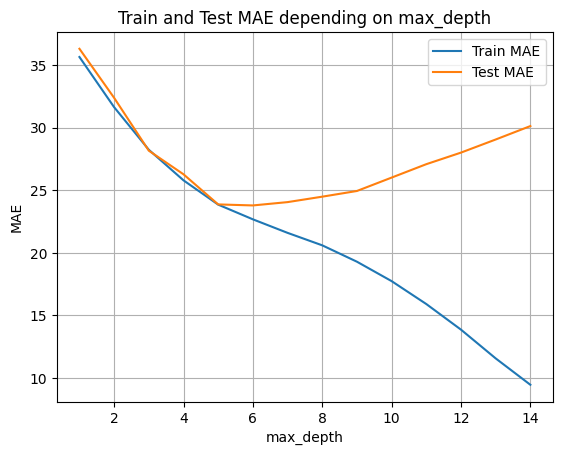

In [56]:
# код для візуалізації
# вам потрібно створити список max_depthes зі значеннями параметра який ви використовували
import matplotlib.pyplot as plt

plt.plot(max_depth, train_MAE, label="Train MAE")
plt.plot(max_depth, test_MAE, label="Test MAE")

plt.xlabel("max_depth")
plt.ylabel("MAE")
plt.title("Train and Test MAE depending on max_depth")
plt.legend()
plt.grid()

plt.show()

# Завдання 7
По графіку визначте оптимальне значення параметра `max_depth`

Оптимальне значення параметра `max_depth` по '**MAE**' буде дорівнювати = **6**, тому що:

* **Досягнуто мінімуму помилки на тесті:** На графіку помаранчева крива (Test MAE) досягає свого найнижчого значення саме при max_depth = 6 (помилка падає до ~23.78).
* **Баланс між недонавчанням та перенавчанням:** При глибині більше 6 починається перенавчання моделі.

In [59]:
# Тренуємо модель та рахуємо метрику 'MSE' (Mean Squared Error) — середньоквадратична похибка

train_MSE = []
test_MSE = []

max_depth = range(1, 15)

for depth in max_depth:
  tree = DecisionTreeRegressor(max_depth=depth)
  tree.fit(X_train, y_train)

  train_predict = tree.predict(X_train)
  test_predict = tree.predict(X_test)

  MSE_test = mean_squared_error(y_test, test_predict)
  MSE_train = mean_squared_error(y_train, train_predict)

  train_MSE.append(MSE_train)
  test_MSE.append(MSE_test)

In [60]:
train_MSE

[2003.306289219283,
 1597.5110564868583,
 1242.0583324762952,
 1052.8473983436695,
 893.1527738202321,
 820.2846642403358,
 754.6176301780897,
 693.508734009944,
 625.4375948352368,
 550.5283614621612,
 469.24647300437925,
 384.78393731805335,
 303.5467538627971,
 236.58985410266794]

In [61]:
test_MSE

[2052.9013123604573,
 1636.7373508857531,
 1238.289095804986,
 1092.3529651795318,
 904.500386789135,
 889.2331008254794,
 914.5975320723916,
 971.6425154018858,
 1025.2179490234066,
 1118.959505135633,
 1228.8224174652935,
 1318.1236708950487,
 1410.8032960927742,
 1469.7174629895942]

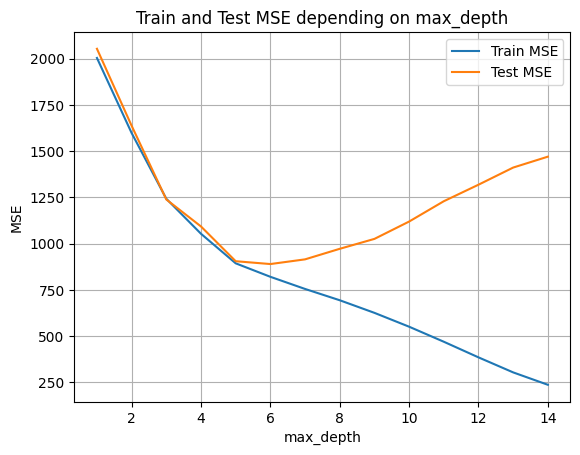

In [62]:
# код для візуалізації
# вам потрібно створити список max_depthes зі значеннями параметра який ви використовували
import matplotlib.pyplot as plt

plt.plot(max_depth, train_MSE, label="Train MSE")
plt.plot(max_depth, test_MSE, label="Test MSE")

plt.xlabel("max_depth")
plt.ylabel("MSE")
plt.title("Train and Test MSE depending on max_depth")
plt.legend()
plt.grid()

plt.show()

Оптимальне значення параметра `max_depth` за метрикою **MSE** також дорівнює **6** (або **5–6**), тому що:

* **Мінімум помилки MSE на тестових даних:** Помаранчева крива (`Test MSE`) досягає найнижчої точки саме при `max_depth = 6` (значення MSE падає до найменшого рівня ~890).


* **Пліч-о-пліч із метрикою MAE:** Графік повністю підтверджує попередній аналіз по MAE. При глибині більше 6 середня квадратична помилка на тесті починає стрімко зростати через штрафування великих відхилень у **перенавченій моделі**.



Отже, глибина **6** є універсально оптимальною для цієї моделі за обома метриками якості!

In [63]:
# Тренуємо модель та рахуємо метрику R² (коефіцієнт детермінації)

train_R2 = []
test_R2 = []

max_depth = range(1, 15)

for depth in max_depth:
  tree = DecisionTreeRegressor(max_depth=depth)
  tree.fit(X_train, y_train)

  train_predict = tree.predict(X_train)
  test_predict = tree.predict(X_test)

  R2_test = r2_score(y_test, test_predict)
  R2_train = r2_score(y_train, train_predict)

  train_R2.append(R2_train)
  test_R2.append(R2_test)

In [64]:
train_R2

[0.42109795690757357,
 0.5383619472270555,
 0.6410782963244648,
 0.6957552056589283,
 0.7419026893986833,
 0.7629596279901977,
 0.7819356479762724,
 0.7995944877818666,
 0.81926522997238,
 0.8409119988561641,
 0.8644002949533917,
 0.8888077131982753,
 0.9122830907430889,
 0.931631847485314]

In [65]:
test_R2

[0.41778294741058264,
 0.5358099336981699,
 0.6488126227635215,
 0.6902011217271471,
 0.7434774160396207,
 0.7478073242438192,
 0.7390574465594502,
 0.7247561588272429,
 0.7054111827872303,
 0.6761544001180909,
 0.653366310856966,
 0.6238567141710458,
 0.6081306281301835,
 0.5848901606024395]

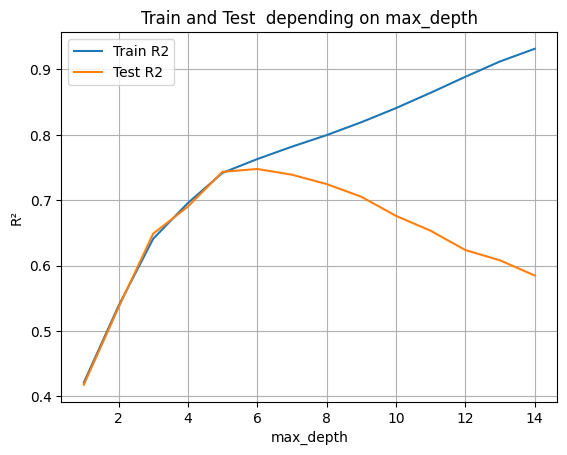

In [66]:
# код для візуалізації
# вам потрібно створити список max_depthes зі значеннями параметра який ви використовували
import matplotlib.pyplot as plt

plt.plot(max_depth, train_R2, label="Train R2")
plt.plot(max_depth, test_R2, label="Test R2")

plt.xlabel("max_depth")
plt.ylabel("R²")
plt.title("Train and Test  depending on max_depth")
plt.legend()
plt.grid()

plt.show()

Оптимальне значення параметра max_depth за коефіцієнтом детермінації $R^2$ також дорівнює 6, тому що:

* Максимум точності на тесті: Помаранчева крива (Test R2) досягає свого піка саме при max_depth = 6 (пояснюючи найвищий відсоток дисперсії даних — близько 75%).   
* Підтвердження перенавчання: Після глибини 6 тренувальний $R^2$ продовжує зростати до ~93%, а тестовий $R^2$ стрімко падає до 58%. Це остаточно доводить, що збільшення глибини понад 6 призводить до перенавчання моделі.

Таким чином, усі три метрики (MAE, MSE та $R^2$) одностайно вказують на max_depth = 6 як на ідеальну глибину для даного дерева!